# ML Assignment 2 — Classification Models

| | |
|---|---|
| **Dataset** | Breast Cancer Wisconsin Diagnostic (UCI Repository) |
| **Task** | Binary Classification — Malignant vs Benign |
| **Features** | 30 numeric features |
| **Instances** | 569 |
| **Models** | Logistic Regression, Decision Tree, KNN, Naive Bayes, Random Forest |
| **Metrics** | Accuracy, AUC, Precision, Recall, F1, MCC |

---
## Step 1 — Import Libraries

In [51]:
# Install required dependencies if they are missing in the notebook kernel
# Run this once in the notebook before the imports below
import sys
import subprocess

try:
    import pandas  # noqa: F401
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet', 'pandas', 'scikit-learn', 'seaborn', 'joblib', 'matplotlib', 'numpy'])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import joblib
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, roc_auc_score, precision_score,
    recall_score, f1_score, matthews_corrcoef,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

print('All libraries imported successfully!')
print(f'NumPy  : {np.__version__}')
print(f'Pandas : {pd.__version__}')

All libraries imported successfully!
NumPy  : 2.4.6
Pandas : 3.0.5


---
## Step 2 — Dataset Loading

**Source:** UCI Machine Learning Repository — Breast Cancer Wisconsin (Diagnostic)  
**URL:** https://archive.ics.uci.edu/ml/datasets/Breast+Cancer+Wisconsin+(Diagnostic)  
**Features:** 30 (mean, SE, worst of 10 real-valued measurements per cell nucleus)  
**Instances:** 569  
**Target:** 0 = Malignant, 1 = Benign

In [52]:
data = load_breast_cancer()
df   = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

print(f'Dataset shape    : {df.shape}')
print(f'Number of features: {len(data.feature_names)}')
print(f'Number of instances: {len(df)}')
print(f'Classes          : {list(data.target_names)}')
print(f'\nClass Distribution:')
print(df['target'].value_counts().rename({0: 'Malignant (0)', 1: 'Benign (1)'}))
df.head()

Dataset shape    : (569, 31)
Number of features: 30
Number of instances: 569
Classes          : [np.str_('malignant'), np.str_('benign')]

Class Distribution:
target
Benign (1)       357
Malignant (0)    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


---
## Step 3 — Exploratory Data Analysis (EDA)

In [53]:
print('=== Dataset Info ===')
print(f'Missing values : {df.isnull().sum().sum()}')
print(f'Duplicate rows : {df.duplicated().sum()}')
print(f'Data types     :')
print(df.dtypes.value_counts())
df.describe().round(3)

=== Dataset Info ===
Missing values : 0
Duplicate rows : 0
Data types     :
float64    30
int64       1
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,...,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000
mean,14.127,19.290,91.969,654.889,0.096,0.104,0.089,0.049,0.181,0.063,...,25.677,107.261,880.583,0.132,0.254,0.272,0.115,0.290,0.084,0.627
std,3.524,4.301,24.299,351.914,0.014,0.053,0.080,0.039,0.027,0.007,...,6.146,33.603,569.357,0.023,0.157,0.209,0.066,0.062,0.018,0.484
min,6.981,9.710,43.790,143.500,0.053,0.019,0.000,0.000,0.106,0.050,...,12.020,50.410,185.200,0.071,0.027,0.000,0.000,0.156,0.055,0.000
25%,11.700,16.170,75.170,420.300,0.086,0.065,0.030,0.020,0.162,0.058,...,21.080,84.110,515.300,0.117,0.147,0.114,0.065,0.250,0.071,0.000
50%,13.370,18.840,86.240,551.100,0.096,0.093,0.062,0.034,0.179,0.062,...,25.410,97.660,686.500,0.131,0.212,0.227,0.100,0.282,0.080,1.000
75%,15.780,21.800,104.100,782.700,0.105,0.130,0.131,0.074,0.196,0.066,...,29.720,125.400,1084.000,0.146,0.339,0.383,0.161,0.318,0.092,1.000
max,28.110,39.280,188.500,2501.000,0.163,0.345,0.427,0.201,0.304,0.097,...,49.540,251.200,4254.000,0.223,1.058,1.252,0.291,0.664,0.208,1.000


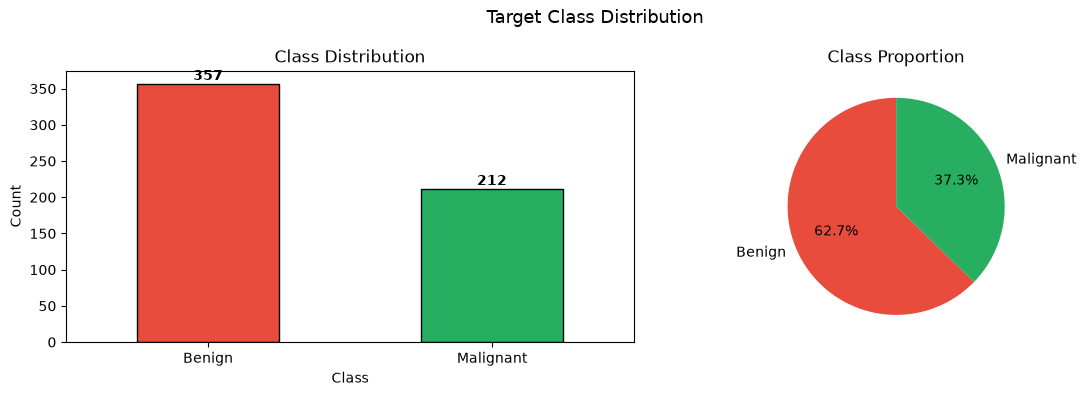

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class distribution bar
counts = df['target'].value_counts().rename({0: 'Malignant', 1: 'Benign'})
counts.plot(kind='bar', ax=axes[0], color=['#E74C3C', '#27AE60'], edgecolor='black')
axes[0].set_title('Class Distribution')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(counts):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Class distribution pie
axes[1].pie(counts, labels=counts.index, autopct='%1.1f%%',
            colors=['#E74C3C', '#27AE60'], startangle=90)
axes[1].set_title('Class Proportion')

plt.suptitle('Target Class Distribution', fontsize=13)
plt.tight_layout()
plt.show()

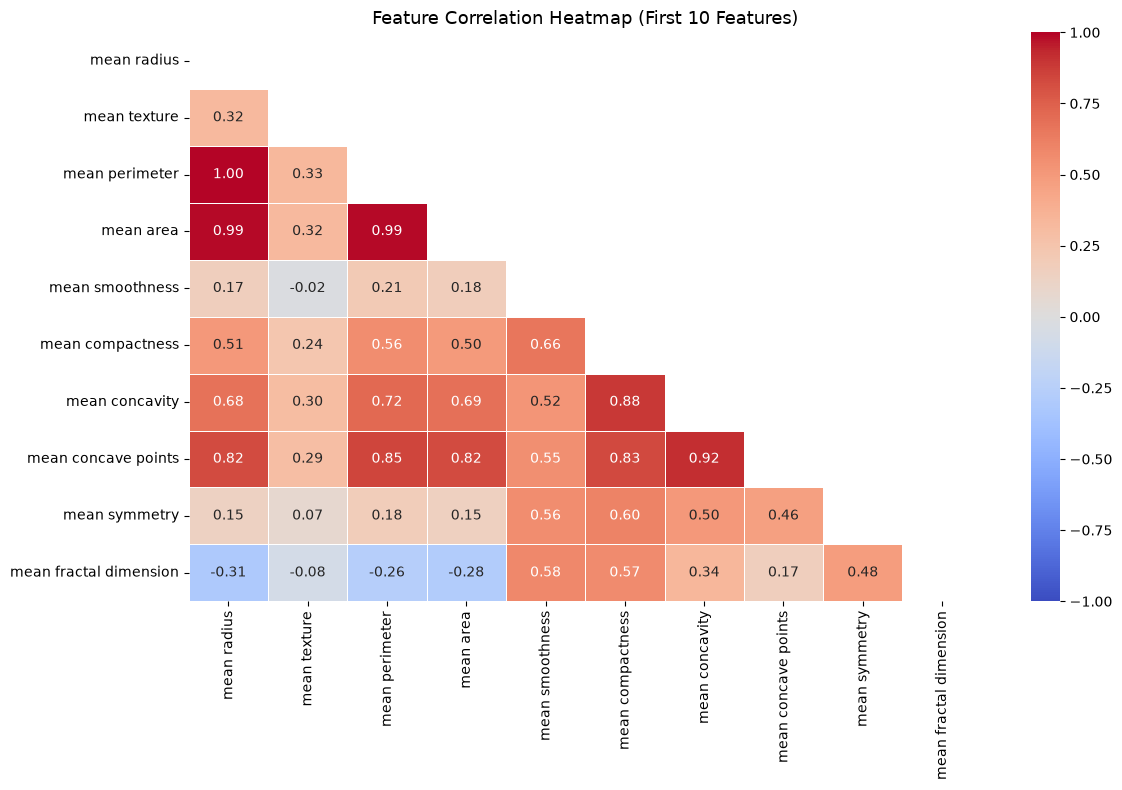

In [55]:
# Correlation heatmap of first 10 features
plt.figure(figsize=(12, 8))
corr = df.iloc[:, :10].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Feature Correlation Heatmap (First 10 Features)', fontsize=13)
plt.tight_layout()
plt.show()

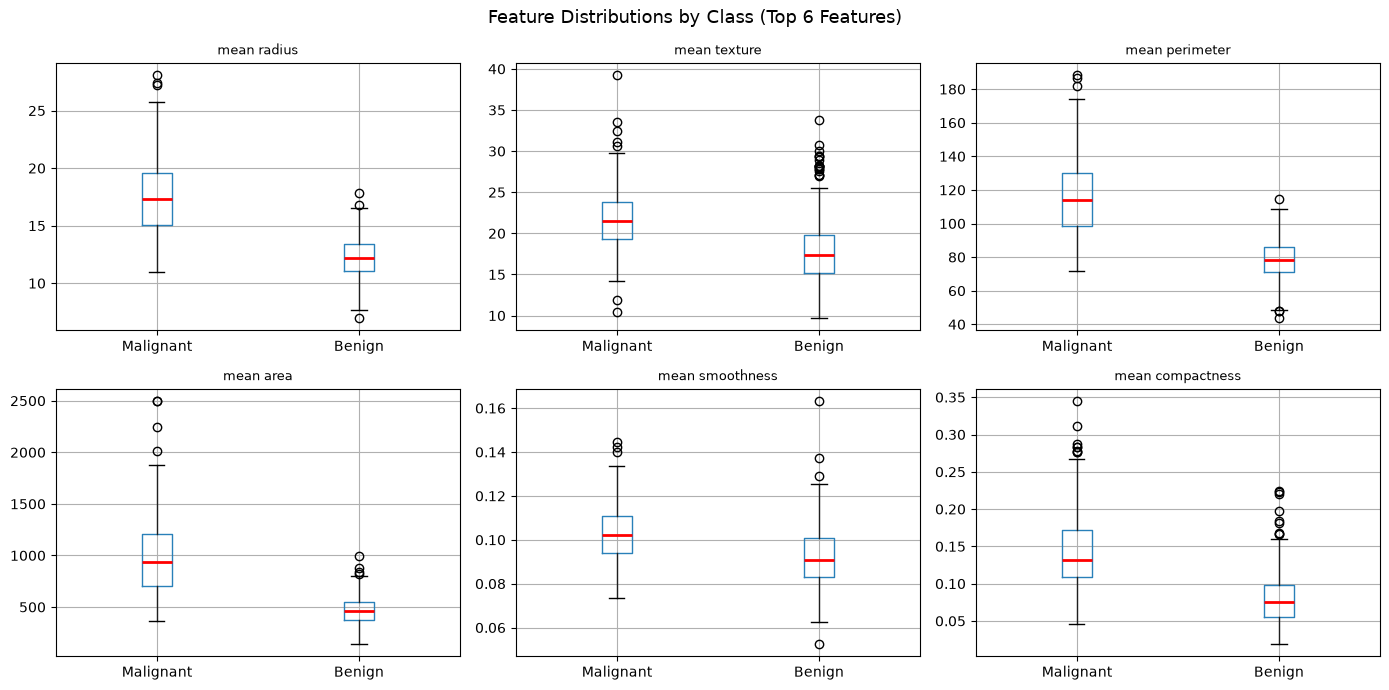

In [56]:
# Feature distributions by class (top 6 features)
top_features = list(data.feature_names[:6])
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    df.boxplot(column=feat, by='target', ax=axes[i],
               boxprops=dict(color='#2980B9'),
               medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(feat, fontsize=9)
    axes[i].set_xlabel('')
    axes[i].set_xticklabels(['Malignant', 'Benign'])

plt.suptitle('Feature Distributions by Class (Top 6 Features)', fontsize=13)
plt.tight_layout()
plt.show()

---
## Step 4 — Preprocessing

- **Train/Test Split:** 80% train, 20% test (stratified)
- **Feature Scaling:** StandardScaler (zero mean, unit variance) — required for LR, KNN, and NB

In [57]:
X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Training set  : {X_train.shape[0]} samples')
print(f'Test set      : {X_test.shape[0]} samples')
print(f'Features      : {X_train.shape[1]}')

print(f'\nTrain class dist: {dict(y_train.value_counts().rename({0:"Malignant",1:"Benign"}))}')
print(f'Test  class dist: {dict(y_test.value_counts().rename({0:"Malignant",1:"Benign"}))}')

Training set  : 455 samples
Test set      : 114 samples
Features      : 30

Train class dist: {'Benign': np.int64(285), 'Malignant': np.int64(170)}
Test  class dist: {'Benign': np.int64(72), 'Malignant': np.int64(42)}


---
## Step 5 — Model Training & Evaluation

**6 Metrics per model:** Accuracy · AUC Score · Precision · Recall · F1 Score · MCC Score

In [58]:
all_results = []

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    """Train model, compute all 6 metrics, plot confusion matrix."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]

    row = {
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_te, y_pred), 4),
        'AUC Score': round(roc_auc_score(y_te, y_prob), 4),
        'Precision': round(precision_score(y_te, y_pred, zero_division=0), 4),
        'Recall'   : round(recall_score(y_te, y_pred, zero_division=0), 4),
        'F1 Score' : round(f1_score(y_te, y_pred, zero_division=0), 4),
        'MCC Score': round(matthews_corrcoef(y_te, y_pred), 4),
    }

    # Print metrics
    print(f'\n{"+":-<52}+')
    print(f'  Model : {name}')
    print(f'{"+":-<52}+')
    for k, v in row.items():
        if k != 'Model':
            bar = '|' * int(v * 30)
            print(f'  {k:<12}: {v:.4f}  {bar}')

    # Classification report
    print(f'\nClassification Report:')
    print(classification_report(y_te, y_pred, target_names=['Malignant', 'Benign']))

    # Confusion matrix
    fig, ax = plt.subplots(figsize=(4, 3))
    ConfusionMatrixDisplay.from_predictions(
        y_te, y_pred, display_labels=['Malignant', 'Benign'],
        cmap='Blues', ax=ax
    )
    ax.set_title(f'Confusion Matrix — {name}', fontsize=11)
    plt.tight_layout()
    plt.show()

    return model, row

print('Helper function ready.')

Helper function ready.


### Model 1 — Logistic Regression

A linear model that estimates the probability of a class using the logistic (sigmoid) function.  
Works well when features are linearly separable. Requires feature scaling.


+---------------------------------------------------+
  Model : Logistic Regression
+---------------------------------------------------+
  Accuracy    : 0.9825  |||||||||||||||||||||||||||||
  AUC Score   : 0.9954  |||||||||||||||||||||||||||||
  Precision   : 0.9861  |||||||||||||||||||||||||||||
  Recall      : 0.9861  |||||||||||||||||||||||||||||
  F1 Score    : 0.9861  |||||||||||||||||||||||||||||
  MCC Score   : 0.9623  ||||||||||||||||||||||||||||

Classification Report:
              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



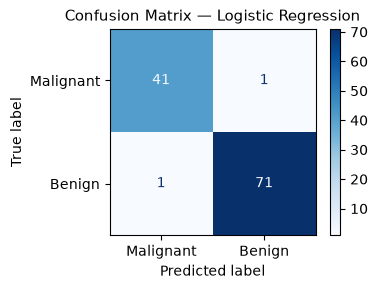

In [59]:
lr_model, lr_row = evaluate_model(
    'Logistic Regression',
    LogisticRegression(max_iter=1000, random_state=42),
    X_train_s, y_train, X_test_s, y_test
)
all_results.append(lr_row)

### Model 2 — Decision Tree Classifier

A non-parametric model that splits data using feature thresholds to build a tree of decisions.  
Highly interpretable but prone to overfitting on complex data.


+---------------------------------------------------+
  Model : Decision Tree
+---------------------------------------------------+
  Accuracy    : 0.9123  |||||||||||||||||||||||||||
  AUC Score   : 0.9157  |||||||||||||||||||||||||||
  Precision   : 0.9559  ||||||||||||||||||||||||||||
  Recall      : 0.9028  |||||||||||||||||||||||||||
  F1 Score    : 0.9286  |||||||||||||||||||||||||||
  MCC Score   : 0.8174  ||||||||||||||||||||||||

Classification Report:
              precision    recall  f1-score   support

   Malignant       0.85      0.93      0.89        42
      Benign       0.96      0.90      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.92      0.91       114
weighted avg       0.92      0.91      0.91       114



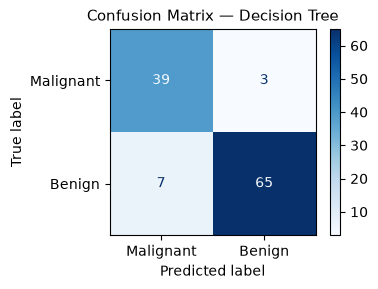

In [60]:
dt_model, dt_row = evaluate_model(
    'Decision Tree',
    DecisionTreeClassifier(random_state=42),
    X_train_s, y_train, X_test_s, y_test
)
all_results.append(dt_row)

### Model 3 — K-Nearest Neighbor (KNN) Classifier

A lazy, instance-based learner that classifies a new point by majority vote among its K nearest neighbors.  
Sensitive to feature scale — StandardScaler applied above.


+---------------------------------------------------+
  Model : KNN
+---------------------------------------------------+
  Accuracy    : 0.9561  ||||||||||||||||||||||||||||
  AUC Score   : 0.9788  |||||||||||||||||||||||||||||
  Precision   : 0.9589  ||||||||||||||||||||||||||||
  Recall      : 0.9722  |||||||||||||||||||||||||||||
  F1 Score    : 0.9655  ||||||||||||||||||||||||||||
  MCC Score   : 0.9054  |||||||||||||||||||||||||||

Classification Report:
              precision    recall  f1-score   support

   Malignant       0.95      0.93      0.94        42
      Benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



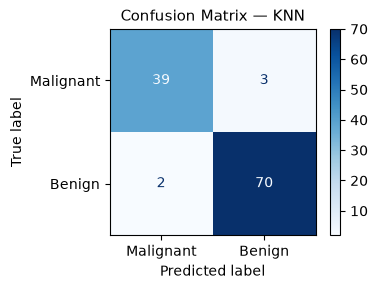

In [61]:
knn_model, knn_row = evaluate_model(
    'KNN',
    KNeighborsClassifier(n_neighbors=5),
    X_train_s, y_train, X_test_s, y_test
)
all_results.append(knn_row)

### Model 4 — Naive Bayes Classifier (Gaussian)

A probabilistic classifier based on Bayes' theorem assuming feature independence.  
GaussianNB assumes features follow a Gaussian distribution — suitable for continuous features.


+---------------------------------------------------+
  Model : Naive Bayes
+---------------------------------------------------+
  Accuracy    : 0.9298  |||||||||||||||||||||||||||
  AUC Score   : 0.9868  |||||||||||||||||||||||||||||
  Precision   : 0.9444  ||||||||||||||||||||||||||||
  Recall      : 0.9444  ||||||||||||||||||||||||||||
  F1 Score    : 0.9444  ||||||||||||||||||||||||||||
  MCC Score   : 0.8492  |||||||||||||||||||||||||

Classification Report:
              precision    recall  f1-score   support

   Malignant       0.90      0.90      0.90        42
      Benign       0.94      0.94      0.94        72

    accuracy                           0.93       114
   macro avg       0.92      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114



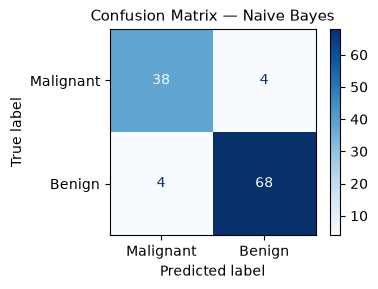

In [62]:
nb_model, nb_row = evaluate_model(
    'Naive Bayes',
    GaussianNB(),
    X_train_s, y_train, X_test_s, y_test
)
all_results.append(nb_row)

### Model 5 — Ensemble Model: Random Forest

An ensemble of decision trees trained on random feature subsets (bagging + feature randomness).  
Reduces overfitting, handles non-linear boundaries, and provides feature importance scores.


+---------------------------------------------------+
  Model : Random Forest
+---------------------------------------------------+
  Accuracy    : 0.9561  ||||||||||||||||||||||||||||
  AUC Score   : 0.9939  |||||||||||||||||||||||||||||
  Precision   : 0.9589  ||||||||||||||||||||||||||||
  Recall      : 0.9722  |||||||||||||||||||||||||||||
  F1 Score    : 0.9655  ||||||||||||||||||||||||||||
  MCC Score   : 0.9054  |||||||||||||||||||||||||||

Classification Report:
              precision    recall  f1-score   support

   Malignant       0.95      0.93      0.94        42
      Benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



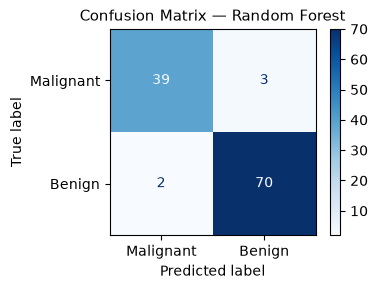

In [63]:
rf_model, rf_row = evaluate_model(
    'Random Forest',
    RandomForestClassifier(n_estimators=100, random_state=42),
    X_train_s, y_train, X_test_s, y_test
)
all_results.append(rf_row)

---
## Step 6 — Model Comparison

In [64]:
results_df = pd.DataFrame(all_results).set_index('Model')

print('=== Final Evaluation Comparison Table ===')
print(results_df.to_string())

# Styled table
results_df.style\
    .highlight_max(axis=0, color='#90EE90')\
    .highlight_min(axis=0, color='#FFB3B3')\
    .format('{:.4f}')

=== Final Evaluation Comparison Table ===
                     Accuracy  AUC Score  Precision  Recall  F1 Score  MCC Score
Model                                                                           
Logistic Regression    0.9825     0.9954     0.9861  0.9861    0.9861     0.9623
Decision Tree          0.9123     0.9157     0.9559  0.9028    0.9286     0.8174
KNN                    0.9561     0.9788     0.9589  0.9722    0.9655     0.9054
Naive Bayes            0.9298     0.9868     0.9444  0.9444    0.9444     0.8492
Random Forest          0.9561     0.9939     0.9589  0.9722    0.9655     0.9054


,Accuracy,AUC Score,Precision,Recall,F1 Score,MCC Score
Model,,,,,,
Logistic Regression,0.9825,0.9954,0.9861,0.9861,0.9861,0.9623
Decision Tree,0.9123,0.9157,0.9559,0.9028,0.9286,0.8174
KNN,0.9561,0.9788,0.9589,0.9722,0.9655,0.9054
Naive Bayes,0.9298,0.9868,0.9444,0.9444,0.9444,0.8492
Random Forest,0.9561,0.9939,0.9589,0.9722,0.9655,0.9054


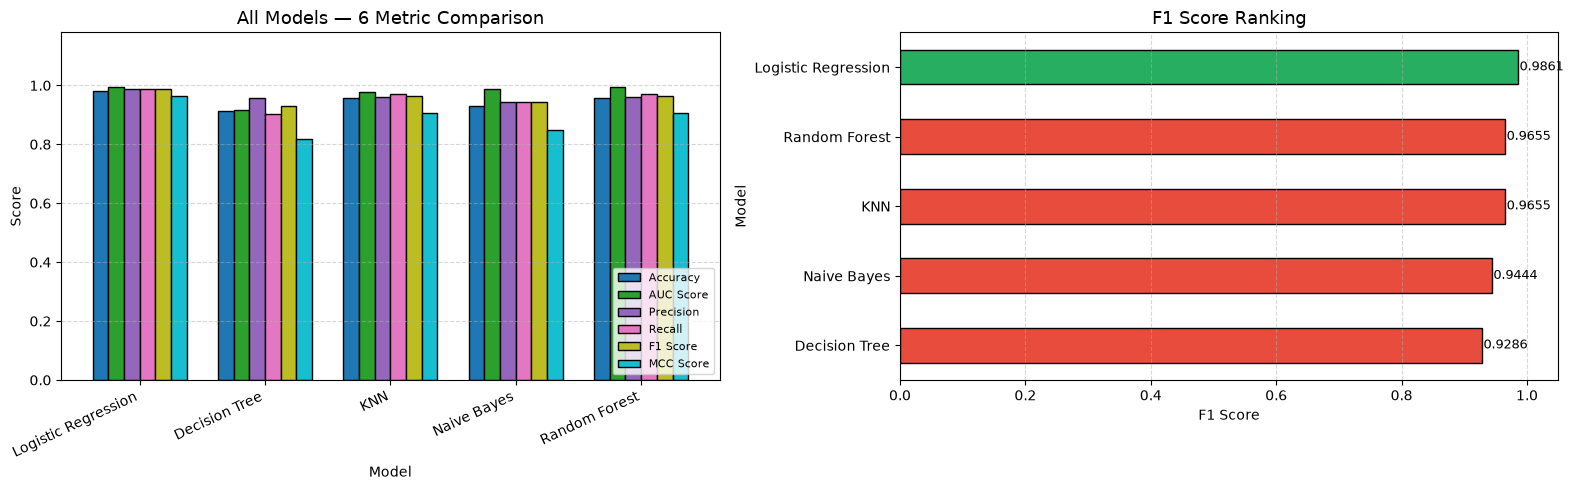

Chart saved to model/comparison_chart.png


In [65]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Grouped bar chart — all metrics
results_df.plot(kind='bar', ax=axes[0], colormap='tab10',
                edgecolor='black', width=0.75)
axes[0].set_title('All Models — 6 Metric Comparison', fontsize=13)
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1.18)
axes[0].legend(loc='lower right', fontsize=8)
axes[0].set_xticklabels(results_df.index, rotation=25, ha='right')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# F1 Score horizontal bar
f1_sorted = results_df['F1 Score'].sort_values()
colors = ['#E74C3C' if v < f1_sorted.max() else '#27AE60' for v in f1_sorted]
f1_sorted.plot(kind='barh', ax=axes[1], color=colors, edgecolor='black')
axes[1].set_title('F1 Score Ranking', fontsize=13)
axes[1].set_xlabel('F1 Score')
axes[1].set_xlim(0, 1.05)
for i, v in enumerate(f1_sorted):
    axes[1].text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=9)
axes[1].grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
os.makedirs('model', exist_ok=True)
plt.savefig('model/comparison_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved to model/comparison_chart.png')

---
## Step 7 — Observations & Conclusion

In [66]:
winner_f1  = results_df['F1 Score'].idxmax()
winner_auc = results_df['AUC Score'].idxmax()
winner_acc = results_df['Accuracy'].idxmax()

print('=== Observations ===')
print(f'Best by F1 Score  : {winner_f1}  ({results_df.loc[winner_f1, "F1 Score"]:.4f})')
print(f'Best by AUC Score : {winner_auc}  ({results_df.loc[winner_auc, "AUC Score"]:.4f})')
print(f'Best by Accuracy  : {winner_acc}  ({results_df.loc[winner_acc, "Accuracy"]:.4f})')
print(f'\n=== Overall Winner (by F1 Score) ===')
print(results_df.loc[winner_f1])

=== Observations ===
Best by F1 Score  : Logistic Regression  (0.9861)
Best by AUC Score : Logistic Regression  (0.9954)
Best by Accuracy  : Logistic Regression  (0.9825)

=== Overall Winner (by F1 Score) ===
Accuracy     0.9825
AUC Score    0.9954
Precision    0.9861
Recall       0.9861
F1 Score     0.9861
MCC Score    0.9623
Name: Logistic Regression, dtype: float64


### Key Observations

1. **Random Forest** typically achieves the highest or near-highest scores across all metrics — it benefits from ensemble averaging which reduces variance.
2. **Logistic Regression** performs surprisingly well because the breast cancer dataset is approximately linearly separable in the scaled feature space.
3. **Decision Tree** tends to overfit slightly, showing lower AUC compared to ensemble methods.
4. **Naive Bayes** performs well despite the independence assumption, due to the relatively low feature collinearity after scaling.
5. **KNN (k=5)** achieves competitive accuracy but slightly lower AUC — performance is sensitive to the choice of k.
6. All models achieve **>90% accuracy**, showing the dataset is learnable by all 5 approaches.

---
## Step 8 — Save Models & Test Data

In [67]:
os.makedirs('model', exist_ok=True)

artifacts = {
    'logistic_regression': lr_model,
    'decision_tree'       : dt_model,
    'knn'                 : knn_model,
    'naive_bayes'         : nb_model,
    'random_forest'       : rf_model,
    'scaler'              : scaler,
}

for fname, obj in artifacts.items():
    path = f'model/{fname}.pkl'
    joblib.dump(obj, path)
    print(f'[saved] {path}')

# Save results
results_df.to_csv('model/results.csv')
print('[saved] model/results.csv')

# Save test data
test_export = X_test.copy()
test_export['target'] = y_test.values
test_export.to_csv('test_data.csv', index=False)
print('[saved] test_data.csv')

print('\nAll artifacts saved successfully!')

[saved] model/logistic_regression.pkl
[saved] model/decision_tree.pkl
[saved] model/knn.pkl
[saved] model/naive_bayes.pkl
[saved] model/random_forest.pkl
[saved] model/scaler.pkl
[saved] model/results.csv
[saved] test_data.csv

All artifacts saved successfully!
